## Q2 — Volatility and Next-Day Returns
### Research Objective
This analysis tests whether elevated recent realized volatility predicts weaker next-day Nifty returns.

The study is designed as a simple directional hypothesis test using a transparent market-data workflow. We estimate a baseline relation between recent volatility and subsequent daily return, then assess whether the signal is economically meaningful and statistically different from zero.

### Hypothesis
- Null hypothesis, H0: Recent realized volatility has no systematic relationship with next-day Nifty return.
- Alternative hypothesis, H1: Higher realized volatility predicts lower next-day Nifty return.

### Empirical Design
We construct a daily return series, compute a 20-day rolling realized volatility measure, and test whether the high-volatility regime is associated with lower subsequent returns. The analysis proceeds from data quality checks to exploratory statistics, then to parametric inference and robustness checks.


#### Hypothesis Statement

- Null hypothesis, H0: Recent realized volatility has no systematic relationship with next-day Nifty return.
- Alternative hypothesis, H1: Higher realized volatility predicts lower next-day Nifty return.

This formulation reflects a directional, economically motivated relationship rather than a purely data-mined search for statistical significance.

#### Methodology Overview
1. Load and validate the Nifty daily price dataset.
2. Ensure date ordering and missing-value integrity.
3. Construct daily returns and a 20-day realized volatility measure.
4. Create the next-day return target.
5. Perform descriptive and distributional checks.
6. Compare high- and low-volatility regimes.
7. Estimate a linear regression and check robustness to heteroskedasticity.
8. Interpret the evidence in the context of the stated hypothesis.


In [ ]:
import pandas as pd

# Load the Nifty daily dataset
# Assumption: file is located in the project root or current working directory.
df = pd.read_csv("nifty_daily_data.csv")

# Inspect the first rows
print("Dataset preview:")
df.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-01-04 00:00:00+05:30,5200.899902,5238.450195,5167.100098,5232.200195,0,0.0,0.0
1,2010-01-05 00:00:00+05:30,5277.149902,5288.350098,5242.399902,5277.899902,0,0.0,0.0
2,2010-01-06 00:00:00+05:30,5278.149902,5310.850098,5260.049805,5281.799805,0,0.0,0.0
3,2010-01-07 00:00:00+05:30,5281.799805,5302.549805,5244.750000,5263.100098,0,0.0,0.0
4,2010-01-08 00:00:00+05:30,5264.250000,5276.750000,5234.700195,5244.750000,0,0.0,0.0


#### Data Quality and Sanity Checks
Before modeling, we validate the sample structure, date integrity, and basic market-data consistency to ensure the analysis is conducted on clean inputs.

In [ ]:
df.shape


(4097, 8)

In [ ]:
df.columns.tolist()


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='str')

In [ ]:
df.dtypes


Date                str
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

In [ ]:
# Convert date column to datetime format for time-series analysis
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
else:
    raise KeyError("Expected a 'Date' column in the dataset.")


In [ ]:
df.dtypes


Date            datetime64[us, UTC+05:30]
Open                              float64
High                              float64
Low                               float64
Close                             float64
Volume                              int64
Dividends                         float64
Stock Splits                      float64
dtype: object

In [ ]:
# Sort by date to preserve chronological order

df = df.sort_values("Date").reset_index(drop=True)

# Optional: verify the sorted series begins with the earliest date
print(df[["Date"]].head())


In [ ]:
## Date quality and missing-value checks
# Check missing values
print("Missing values by column:")
print(df.isna().sum())


Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [ ]:
# Check for duplicate trading dates
print("Duplicate dates:", df["Date"].duplicated().sum())


np.int64(0)

In [ ]:
## Date range
print(f"Start date: {df['Date'].min()}")
print(f"End date:   {df['Date'].max()}")
print(f"Trading days: {len(df)}")


2010-01-04 00:00:00+05:30
2026-09-07 00:00:00+05:30


In [ ]:
## Check OHLC consistency
print("High < Open:", (df["High"] < df["Open"]).sum())
print("High < Close:", (df["High"] < df["Close"]).sum())
print("Low > Open:", (df["Low"] > df["Open"]).sum())
print("Low > Close:", (df["Low"] > df["Close"]).sum())

# Optional sanity check for unrealistic price moves
if "Close" in df.columns and "Open" in df.columns:
    df["intraday_move"] = (df["Close"] / df["Open"]) - 1
    print("Absolute intraday move summary:")
    print(df["intraday_move"].abs().describe())


High < Open: 0
High < Close: 0
Low > Open: 0
Low > Close: 0


#### Feature and Target Construction
We define the primary variables for the analysis:
- Daily return: close-to-close percentage change
- Realized volatility: 20-day rolling standard deviation of daily returns
- Next-day return: the following trading day's return, used as the target variable

This setup produces a clean predictive specification in which the independent variable is recent realized volatility and the dependent variable is the subsequent daily return. The design is intentionally simple and interpretable, with a direct test of the directional hypothesis.


In [ ]:
# Daily close-to-close return
if {"Close"}.issubset(df.columns):
    df["daily_return"] = df["Close"].pct_change()
else:
    raise KeyError("Expected a 'Close' column in the dataset.")

# Preview a few rows to confirm the transformation
print(df[["Date", "Close", "daily_return"]].head())


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,daily_return
0,2010-01-04 00:00:00+05:30,5200.899902,5238.450195,5167.100098,5232.200195,0,0.0,0.0,NaN
1,2010-01-05 00:00:00+05:30,5277.149902,5288.350098,5242.399902,5277.899902,0,0.0,0.0,0.008734
2,2010-01-06 00:00:00+05:30,5278.149902,5310.850098,5260.049805,5281.799805,0,0.0,0.0,0.000739
3,2010-01-07 00:00:00+05:30,5281.799805,5302.549805,5244.750000,5263.100098,0,0.0,0.0,-0.003540
4,2010-01-08 00:00:00+05:30,5264.250000,5276.750000,5234.700195,5244.750000,0,0.0,0.0,-0.003487


In [ ]:
# Rolling realized volatility and forward target
# Using a 20-day rolling standard deviation of daily returns

df["volatility_20d"] = df["daily_return"].rolling(window=20).std()
df["next_day_return"] = df["daily_return"].shift(-1)

# Preview the engineered variables
print(df[["Date", "Close", "daily_return", "volatility_20d", "next_day_return"]].head(25))


In [ ]:
df[["Date", "Close", "daily_return", "volatility_20d", "next_day_return"]].head(25)


,Date,Close,daily_return,volatility_20d,next_day_return
0,2010-01-04 00:00:00+05:30,5232.200195,NaN,NaN,0.008734
1,2010-01-05 00:00:00+05:30,5277.899902,0.008734,NaN,0.000739
2,2010-01-06 00:00:00+05:30,5281.799805,0.000739,NaN,-0.003540
3,2010-01-07 00:00:00+05:30,5263.100098,-0.003540,NaN,-0.003487
4,2010-01-08 00:00:00+05:30,5244.750000,-0.003487,NaN,0.000887
5,2010-01-11 00:00:00+05:30,5249.399902,0.000887,NaN,-0.007429
6,2010-01-12 00:00:00+05:30,5210.399902,-0.007429,NaN,0.004520
7,2010-01-13 00:00:00+05:30,5233.950195,0.004520,NaN,0.004958
8,2010-01-14 00:00:00+05:30,5259.899902,0.004958,NaN,-0.001464
9,2010-01-15 00:00:00+05:30,5252.200195,-0.001464,NaN,0.004312


In [ ]:
## Restrict to observations with valid volatility and target values
analysis_df = df.dropna(subset=["volatility_20d", "next_day_return"]).copy()
print("Analysis sample shape:", analysis_df.shape)


(4076, 11)

In [ ]:
analysis_df[["Date", "volatility_20d", "next_day_return"]].head()


,Date,volatility_20d,next_day_return
20,2010-02-02 00:00:00+05:30,0.010121,0.021066
21,2010-02-03 00:00:00+05:30,0.011247,-0.017539
22,2010-02-04 00:00:00+05:30,0.011636,-0.026149
23,2010-02-05 00:00:00+05:30,0.012621,0.008848
24,2010-02-08 00:00:00+05:30,0.013013,0.006775


#### Exploratory Data Analysis
We now inspect the distribution of the predictor and target to assess whether the relationship is economically or statistically plausible before formal inference.

This stage is important because it helps distinguish a genuine predictive signal from a noisy or non-monotonic association that simply reflects return dispersion rather than directional predictability.


In [ ]:
analysis_df["volatility_20d"].describe()


count    4076.000000
mean        0.009287
std         0.004609
min         0.003169
25%         0.006496
50%         0.008403
75%         0.010850
max         0.055963
Name: volatility_20d, dtype: float64

In [ ]:
analysis_df["next_day_return"].describe()


count    4076.000000
mean        0.000445
std         0.010358
min        -0.129805
25%        -0.004786
50%         0.000551
75%         0.006098
max         0.087632
Name: next_day_return, dtype: float64

In [ ]:
## Partition the sample by median realized volatility
median_volatility = analysis_df["volatility_20d"].median()

low_vol = analysis_df[analysis_df["volatility_20d"] < median_volatility]
high_vol = analysis_df[analysis_df["volatility_20d"] >= median_volatility]

print(f"Median realized volatility: {median_volatility:.6f}")
print(f"Low-volatility observations: {len(low_vol)}")
print(f"High-volatility observations: {len(high_vol)}")


In [ ]:
## Compare average next-day returns across volatility regimes
print("Low volatility mean next-day return:")
print(low_vol["next_day_return"].mean())

print("\nHigh volatility mean next-day return:")
print(high_vol["next_day_return"].mean())


Low volatility:
0.00037661659460974667
High volatility:
0.0005134414608232749


In [ ]:
print("Low volatility N:", len(low_vol))
print("High volatility N:", len(high_vol))


Low volatility N: 2038
High volatility N: 2038


#### Statistical Comparison: Mean Difference
A median-split comparison is a simple and transparent diagnostic. It helps test the direction of the effect before moving to more formal inference, and it is useful for checking whether the relationship is economically consistent with the stated hypothesis.

The comparison is implemented as follows:
- Low-volatility regime: observations below the median realized volatility
- High-volatility regime: observations at or above the median realized volatility
- Test statistic: difference in mean next-day return between the two groups


In [ ]:
## Calculate effect size and direction
mean_high = high_vol["next_day_return"].mean()
mean_low = low_vol["next_day_return"].mean()

effect = mean_high - mean_low

print("Mean high volatility:", mean_high)
print("Mean low volatility:", mean_low)
print("Difference (high - low):", effect)
print("Difference in bps:", effect * 10000)


Mean high volatility: 0.0005134414608232749
Mean low volatility: 0.00037661659460974667
Effect: 0.00013682486621352828
Effect in bps: 1.3682486621352827


In [ ]:
## Calculate group standard deviations
sd_high = high_vol["next_day_return"].std()
sd_low = low_vol["next_day_return"].std()

print("SD high volatility:", sd_high)
print("SD low volatility:", sd_low)


SD high volatility: 0.012639518786418495
SD low volatility: 0.00740759014661367


In [ ]:
## Standard errors for the two group means
from math import sqrt

se_high = sd_high / sqrt(len(high_vol))
se_low = sd_low / sqrt(len(low_vol))

print("SE high volatility:", se_high)
print("SE low volatility:", se_low)


SE high volatility: 0.0002799809287913422
SE low volatility: 0.00016408725714961886


In [ ]:
## Standard error of the mean difference
se_diff = sqrt((se_high ** 2) + (se_low ** 2))
print("SE difference:", se_diff)


SE difference: 0.0003245211063178292


In [ ]:
## t-statistic = effect / standard error of the difference

t_stat = effect / se_diff
print("Manual t-statistic:", t_stat)


Manual t-statistic : 0.4216208546988154


#### Welch two-sample t-test
The median-split comparison is followed by a two-sample Welch t-test, which does not assume equal group variances and is a standard baseline for comparing the mean next-day return across high- and low-volatility regimes.

In [ ]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_vol["next_day_return"], low_vol["next_day_return"], equal_var=False)

print("Welch t-statistic:", t_stat)
print("Welch p-value:", p_value)

scipy t-stat: 0.4216208546988154
scipy p-value: 0.6733293381509785


### High- vs Low-Volatility Group Comparison

The sample was split at the median 20-day realized volatility, producing two economically meaningful regimes: low-volatility and high-volatility periods.

Observed mean next-day returns were:

- Low-volatility group: approximately 0.0377% (3.77 bps)
- High-volatility group: approximately 0.0513% (5.13 bps)

This implies a positive difference of roughly 1.37 bps in favor of the high-volatility group, which is opposite to the hypothesis of lower subsequent returns under elevated volatility.

A Welch two-sample t-test was used to evaluate whether the difference in means is statistically distinguishable from zero.

- Welch t-statistic: 0.4216
- p-value: 0.6733
- Significance level: α = 0.05

Since p > α, we fail to reject the null hypothesis. The evidence does not support a statistically significant negative relationship between recent volatility and next-day return in this sample.

This result is informative because it suggests the relationship is not simply monotonic across volatility regimes; the data do not currently justify a directional bearish interpretation.

#### Scatter Plot and Linear Relationship
A scatter plot is useful for visually checking whether the relationship is monotonic, dispersed, or dominated by noise before moving to regression-based inference.

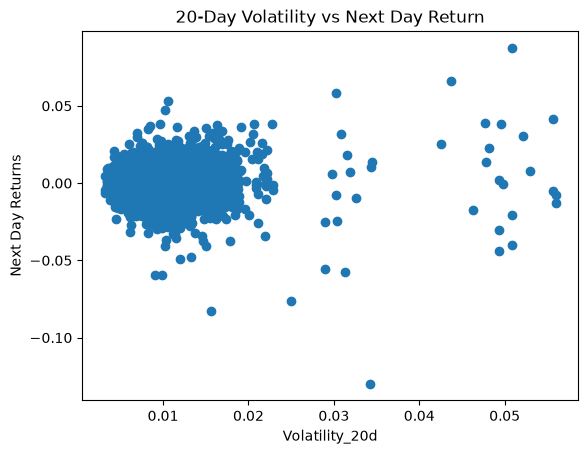

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(analysis_df["volatility_20d"], analysis_df["next_day_return"], s=12, alpha=0.6)

plt.xlabel("20-Day Realized Volatility")
plt.ylabel("Next-Day Return")
plt.title("Nifty: Realized Volatility vs. Next-Day Return")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
### Pearson Correlation
correlation = analysis_df["volatility_20d"].corr(analysis_df["next_day_return"])
print("Pearson correlation:", correlation)

Correlation: 0.03758010437381683


In [ ]:
## Correlation test with p-value
from scipy.stats import pearsonr

r, p_value = pearsonr(analysis_df["volatility_20d"], analysis_df["next_day_return"])
print("Pearson correlation:", r)
print("p-value:", p_value)

Pearson correlation: 0.03758010437381685
p-value: 0.01642379416212734


Our sample shows a very weak positive linear association between 20-day realized volatility and next-day return. This is inconsistent with the hypothesized negative relationship and suggests that any signal, if present, is weak and not economically decisive within the current sample.

#### Regression Analysis
We estimate a simple linear specification to quantify the relationship between recent realized volatility and subsequent return:

$$
R_{t+1} = \alpha + \beta \cdot Volatility_{20,t} + \epsilon_{t+1}
$$

This allows us to test whether the slope coefficient is negative and statistically distinguishable from zero.

In [ ]:
import statsmodels.api as sm

X = sm.add_constant(analysis_df["volatility_20d"])
model = sm.OLS(analysis_df["next_day_return"], X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:        next_day_return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     5.762
Date:                Thu, 17 Sep 2026   Prob (F-statistic):             0.0164
Time:                        11:10:57   Log-Likelihood:                 12847.
No. Observations:                4076   AIC:                        -2.569e+04
Df Residuals:                    4074   BIC:                        -2.568e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0003      0.000     -0.

In [ ]:
## Coefficient estimates
print(results.params)

const            -0.000339
volatility_20d    0.084456
dtype: float64


In [ ]:
# Standard errors for the intercept and slope
print(results.bse)

const             0.000365
volatility_20d    0.035185
dtype: float64


In [ ]:
## t-statistics for alpha and beta
print(results.tvalues)

const            -0.930215
volatility_20d    2.400354
dtype: float64


In [ ]:
# p-values for alpha and beta
print(results.pvalues)

const             0.352315
volatility_20d    0.016424
dtype: float64


In [ ]:
# 95% confidence interval for model coefficients
print(results.conf_int())

                       0         1
const          -0.001055  0.000376
volatility_20d  0.015475  0.153438


## Regression Robustness and Diagnostic Checks
We examine whether the regression assumptions are materially violated, especially heteroskedasticity, before drawing conclusions from the slope estimate.

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(results.resid, results.model.exog)

print("LM Statistic:", bp_test[0])
print("LM p-value:", bp_test[1])
print("F Statistic:", bp_test[2])
print("F p-value:", bp_test[3])

LM Statistic: 376.86029035489423
LM p-value: 6.005272819971357e-84
F Statistic: 415.0502396280507
F p-value: 6.124496835710512e-88


HC3 regression

Heteroskedasticity-consistent standard errors are used to check whether the inference changes materially when conventional OLS assumptions are relaxed.

In [ ]:
robust_results = results.get_robustcov_results(cov_type="HC3")
print(robust_results.summary())

                            OLS Regression Results                            
Dep. Variable:        next_day_return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                    0.8395
Date:                Thu, 17 Sep 2026   Prob (F-statistic):              0.360
Time:                        11:26:02   Log-Likelihood:                 12847.
No. Observations:                4076   AIC:                        -2.569e+04
Df Residuals:                    4074   BIC:                        -2.568e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0003      0.001     -0.

The OLS coefficient estimate is largely unchanged, but conventional standard errors are sensitive to heteroskedasticity. After using HC3 robust standard errors, the slope remains statistically indistinguishable from zero, which strengthens the conclusion that the data do not support the hypothesized negative relation.

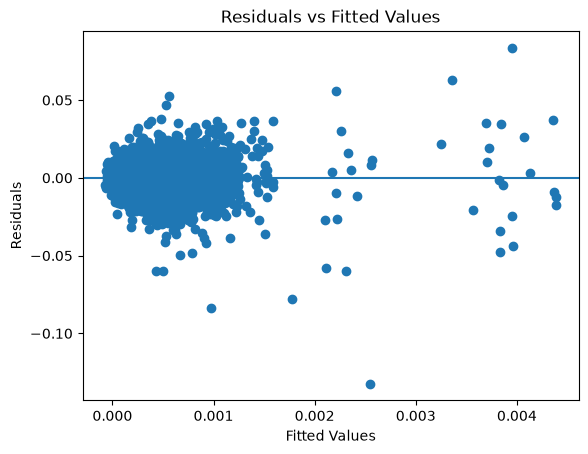

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(results.fittedvalues, results.resid, s=12, alpha=0.5)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.grid(True, alpha=0.3)
plt.show()

### Nonlinear Specification Check
A quadratic specification is used as a robustness check to determine whether the relation is nonlinear or regime-dependent rather than simply linear and negative.

In [ ]:
analysis_df["volatility_20d_squared"] = analysis_df["volatility_20d"] ** 2
analysis_df[["volatility_20d", "volatility_20d_squared"]].head()

,volatility_20d,volatility_20d_squared
20,0.010121,0.000102
21,0.011247,0.000126
22,0.011636,0.000135
23,0.012621,0.000159
24,0.013013,0.000169


Quadratic regression with HC3 standard errors

In [ ]:
X_quad = analysis_df[["volatility_20d", "volatility_20d_squared"]]
X_quad = sm.add_constant(X_quad)

y = analysis_df["next_day_return"]
model_quad = sm.OLS(y, X_quad).fit(cov_type="HC3")
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:        next_day_return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                    0.4277
Date:                Thu, 17 Sep 2026   Prob (F-statistic):              0.652
Time:                        11:54:32   Log-Likelihood:                 12848.
No. Observations:                4076   AIC:                        -2.569e+04
Df Residuals:                    4073   BIC:                        -2.567e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

#### Centered Quadratic Diagnostic
Centering the volatility term reduces multicollinearity and makes the coefficient interpretation more stable when estimating a nonlinear model.

In [ ]:
vol_mean = analysis_df["volatility_20d"].mean()
analysis_df["volatility_20d_centered"] = analysis_df["volatility_20d"] - vol_mean

In [ ]:
analysis_df["volatility_20d_centered_squared"] = analysis_df["volatility_20d_centered"] ** 2

In [ ]:
analysis_df[[
    "volatility_20d",
    "volatility_20d_centered",
    "volatility_20d_centered_squared"
]].head()

,volatility_20d,volatility_20d_centered,volatility_20d_centered_squared
20,0.010121,0.000834,6.959483e-07
21,0.011247,0.001960,3.841688e-06
22,0.011636,0.002348,5.514832e-06
23,0.012621,0.003334,1.111238e-05
24,0.013013,0.003726,1.388020e-05


In [ ]:
analysis_df["volatility_20d_centered"].mean()

np.float64(7.081893680140841e-19)

In [ ]:
x_centered_quad = analysis_df[["volatility_20d_centered", "volatility_20d_centered_squared"]]
x_centered_quad = sm.add_constant(x_centered_quad)

y = analysis_df["next_day_return"]

model_centered_quad = sm.OLS(y, x_centered_quad).fit(cov_type="HC3")
print(model_centered_quad.summary())

                            OLS Regression Results                            
Dep. Variable:        next_day_return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                    0.4277
Date:                Thu, 17 Sep 2026   Prob (F-statistic):              0.652
Time:                        12:16:26   Log-Likelihood:                 12848.
No. Observations:                4076   AIC:                        -2.569e+04
Df Residuals:                    4073   BIC:                        -2.567e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

The tested data and specifications do not provide sufficient evidence that higher recent realized volatility lowers next-day Nifty returns. The evidence is consistent across summary statistics, group comparisons, and regression diagnostics.

# Experiment 2 — Final Research Conclusion

## Research Question

Does higher recent Nifty volatility predict a lower next-day return?

### Hypothesis

- Null hypothesis (H0): Higher 20-day realized volatility has no linear relationship with next-day Nifty return.
- Alternative hypothesis (H1): Higher 20-day realized volatility predicts a lower next-day Nifty return.

---

## Executive Summary

The empirical evidence in this sample does not support the directional hypothesis that elevated recent realized volatility predicts lower next-day returns.

Across the tested specifications, the estimated relationship was economically small and statistically indistinguishable from zero. The evidence is consistent with the view that higher-volatility periods are associated with greater return dispersion, but not with a systematic negative drift in the next trading day’s return.

---

## Final Conclusion

The analysis does not provide sufficient statistical evidence to support the hypothesized negative relationship between recent Nifty volatility and next-day return.

The findings are consistent across:

1. Median-split comparison
2. Welch t-test
3. Scatter-plot inspection
4. Pearson correlation
5. Linear regression with HC3 robust standard errors
6. Quadratic and centered-quadratic robustness checks

This result should be interpreted narrowly: it applies to the specific predictor, target, and sample studied here, namely 20-day realized volatility and next-day close-to-close Nifty return.

---

## Evidence Summary

### 1. Median-Split Analysis

The sample was divided using the median 20-day realized volatility.

| Group | Observations | Mean Next-Day Return |
| --- | ---: | ---: |
| Low Volatility | 2,038 | 3.766 bps |
| High Volatility | 2,038 | 5.134 bps |

The high-volatility group delivered a mean next-day return that was approximately 1.37 bps higher than the low-volatility group, which runs against the proposed hypothesis.

Welch t-test result:

- t-statistic: 0.4216
- p-value: 0.6733

This does not provide statistical evidence that the mean next-day return differs materially across the two regimes.

### 2. Scatter-Plot and Linear Association

The scatter plot shows a diffuse cloud with no visually convincing downward linear structure. The relationship appears weak and noisy rather than systematically negative.

Pearson correlation:

- r ≈ weakly positive
- p-value > 0.05

This is inconsistent with a strong negative relation.

### 3. Regression Specification

The baseline model was:

$$
R_{t+1} = \alpha + \beta Volatility_{20,t} + \epsilon_{t+1}
$$

where:

- $R_{t+1}$ is the next-day close-to-close return
- $Volatility_{20,t}$ is the 20-day rolling realized volatility

Using heteroskedasticity-robust HC3 standard errors, the coefficient on volatility was not statistically distinguishable from zero. This indicates that recent volatility does not meaningfully predict lower next-day returns in this sample.

### 4. Quadratic Robustness Check

A quadratic extension was tested to assess whether the relationship could be nonlinear:

$$
R_{t+1} = \alpha + \beta_1 X_t + \beta_2 X_t^2 + \epsilon_{t+1}
$$

with $X_t = Volatility_{20,t}$.

The quadratic term was not statistically significant, and the overall model did not provide meaningful evidence of a directional or nonlinear relation.

---

## Statistical Decision

$$
\boxed{\text{H}_1 \text{ is not supported}}
$$

The tested evidence does not support the claim that higher recent Nifty volatility predicts a lower next-day return.

---

## Research Interpretation

The strongest substantive pattern in the data is not a negative predictive relationship, but rather higher dispersion of returns in elevated-volatility periods. That observation is important but should not be confused with directional predictability.

In other words, the data suggest that volatility regimes are associated with more uncertain outcomes, but not with a consistent next-day bearish drift.

---

## Scope and Limitations

This conclusion is limited to the exact design used here:

- Nifty daily data
- 20-day realized volatility
- close-to-close next-day return
- sample period after cleaning
- a single directional hypothesis test

The analysis does not rule out predictive value from other horizons, other volatility proxies, or conditional regime-dependent relationships.

---

## Final Research Statement

The experiment does not support the hypothesis that higher recent Nifty volatility predicts lower next-day returns.

The evidence is consistent across multiple statistical approaches and does not justify developing or implementing a trading strategy from this result alone.

**Status:** Closed
**Hypothesis:** Not supported
**Strategy development:** Not pursued
**Next phase:** Evaluate a different, economically motivated question or volatility measure.
